# Memory Experiment — Subsystem Surface Code

**[DEMO]** — Build a planar subsystem surface-code memory with the dedicated
X-then-Z extraction block, inspect its circuit, and decode with CPU MWPM.
Each complete SE cycle uses four CNOT layers per basis.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.noise.config import NoiseConfig
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.subsystem_surface import (
    SubsystemSurfaceCode,
    SubsystemSurfaceCodeExtractionBlock,
)
from lightstim.simulation.decoder_backend import DecoderConfig, SimulationPipeline

In [2]:
distance = 3
basis = "Z"  # "Z" or "X"
p = 1e-3
noise_params = NoiseConfig(p_idle=0, p_1q=0, p_2q=p, p_meas=p, p_reset=p)

In [3]:
code = SubsystemSurfaceCode(distance=distance)
experiment = MemoryExperiment(
    qec_patch=code,
    extraction_block_class=SubsystemSurfaceCodeExtractionBlock,
    rounds=distance,  # complete X/Z cycles
    noise_params=noise_params,
    noise_model="circuit_level",
    basis=basis,
)
circuit = experiment.build()
print(f"Qubits: {circuit.num_qubits}  Detectors: {circuit.num_detectors}")

Qubits: 45  Detectors: 52


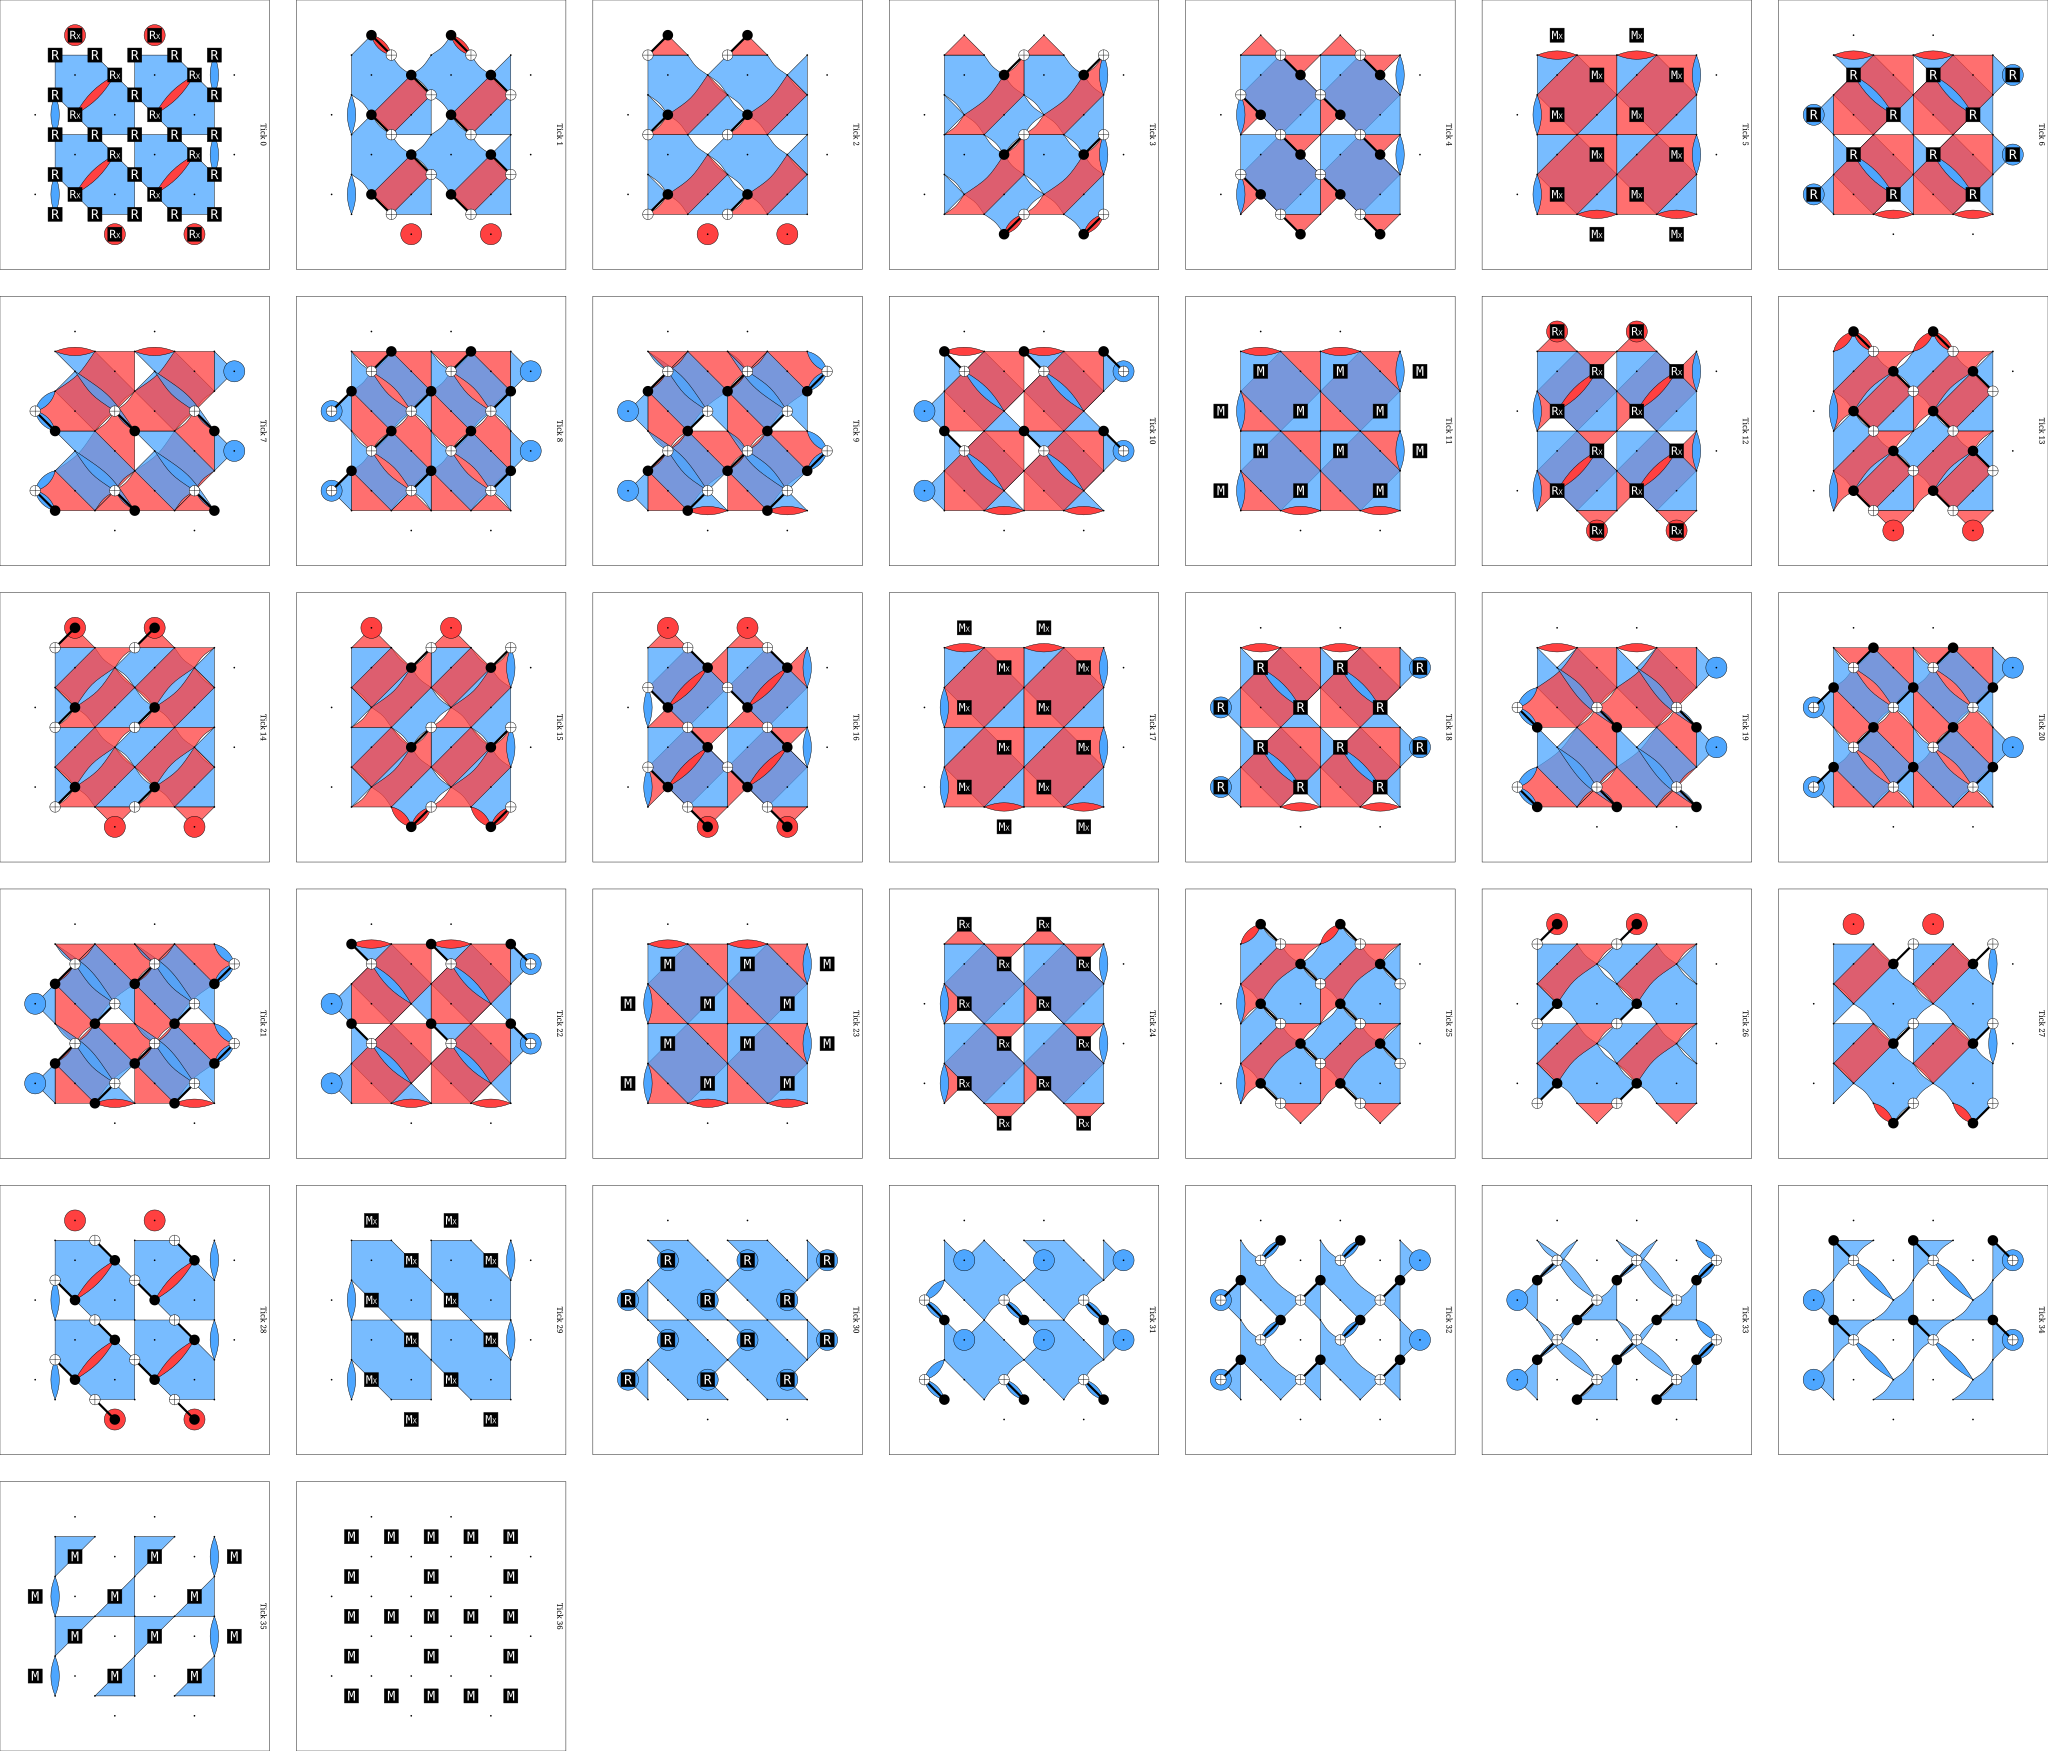

In [4]:
circuit.without_noise().diagram("detslice-with-ops-svg")

## MWPM decoding

Decode the same circuit with CPU PyMatching using all automatically generated
detectors. CNOT, reset and measurement noise use `p`, including final data
readout; idle and one-qubit gate noise are zero.

This small example reports logical failures per complete memory shot.

In [5]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=50_000,
    max_errors=50_001,
    batch_size=10_000,
    num_workers=1,
    print_progress=False,
)
stats = pipeline.run(circuit)
print(f"Logical failures: {stats.errors}/{stats.shots:,}")
print(f"Logical error rate: {stats.logical_error_rate:.3e}")

Logical failures: 59/50,000
Logical error rate: 1.180e-03
